# 05 四个模型对比与 Excel 导出

这个 notebook 把四个模型放在一起比：**线性趋势、移动平均、一次指数平滑、朴素法**。

评估方式和其他 notebook 一样——留出法：前段建模、后段检验，所有指标都按留出段的「实际值 vs 预测值」计算。

> 每个模型的详细公式和推导，见对应的 01 ~ 04 notebook。

## 0. 环境准备（中文字体）

In [1]:
# 中文字体设置：自动适配 Windows / macOS / Linux
import matplotlib
from matplotlib import font_manager

_CAND = ["Microsoft YaHei", "SimHei", "PingFang SC", "Heiti SC",
         "Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Zen Hei",
         "Droid Sans Fallback", "Arial Unicode MS"]
_have = {f.name for f in font_manager.fontManager.ttflist}
_pick = [n for n in _CAND if n in _have]
# 注意：font.family 要传"列表"，matplotlib 才会逐字回退
# （拉丁字母用 DejaVu Sans，中文用上面挑到的字体）
matplotlib.rcParams["font.family"] = _pick + ["DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
print("可用中文字体:", _pick if _pick else "未找到，图中中文可能显示为方框")

可用中文字体: ['Droid Sans Fallback']


## 1. 导入与公用函数

In [2]:
import math
from statistics import NormalDist
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110


def z_value(conf=0.95):
    # 正态分布双侧分位数，95% 对应 1.96
    return NormalDist().inv_cdf(1 - (1 - conf) / 2)


def evaluate(actual, forecast, y, t_index, k=0):
    # 在留出段上计算 SSE / MSE / RMSE / 残差标准误 SE / Theil U1 / U2
    # k = 该模型的待估参数个数（用于 SE 的自由度）
    err = [a - f for a, f in zip(actual, forecast)]
    h = len(actual)
    sse = sum(e * e for e in err)
    rmse = math.sqrt(sse / h)
    se = math.sqrt(sse / max(h - k, 1))
    rms_f = math.sqrt(sum(f * f for f in forecast) / h)
    rms_a = math.sqrt(sum(a * a for a in actual) / h)
    u1 = rmse / (rms_f + rms_a) if (rms_f + rms_a) > 0 else float("nan")
    denom = sum((y[t] - y[t - 1]) ** 2 for t in t_index)
    u2 = math.sqrt(sse / denom) if denom > 0 else float("nan")
    return {"SSE": sse, "MSE": sse / h, "RMSE": rmse, "SE": se,
            "U1": u1, "U2": u2, "误差": err}


def plot_forecast(y, train_n, forecast, se_list, color, title, conf=0.95):
    # 历史观测值 + 该模型对留出段的预测（带预测区间）
    n = len(y)
    z = z_value(conf)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1, train_n + 1), y[:train_n], "-o", color="#424242",
            ms=4, label="观测值（训练段）")
    ax.plot(range(train_n, n + 1), y[train_n - 1:], "-o", color="#9E9E9E",
            ms=5, label="观测值（留出段）")
    xf = list(range(train_n, n + 1))
    yf = [y[train_n - 1]] + list(forecast)
    ax.plot(xf, yf, "--o", color=color, ms=5, label="预测值")
    xh = list(range(train_n + 1, n + 1))
    lo = [f - z * s for f, s in zip(forecast, se_list)]
    hi = [f + z * s for f, s in zip(forecast, se_list)]
    ax.fill_between(xh, lo, hi, color=color, alpha=0.15,
                    label=f"{conf:.0%} 预测区间")
    ax.axvline(train_n + 0.5, color="#BBBBBB", ls=":", lw=1)
    ax.set_xlabel("期数")
    ax.set_ylabel("观测值")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_errors(t_index, err, actual, forecast, color, title):
    # 左：各期误差（正负分色）；右：预测值 vs 实际值散点
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    xs = [f"第{t + 1}期" for t in t_index]
    cols = ["#C62828" if e < 0 else "#2E7D32" for e in err]
    axes[0].bar(xs, err, color=cols)
    axes[0].axhline(0, color="#666", lw=1)
    axes[0].set_title("各期误差（实际值 − 预测值）")
    axes[0].set_ylabel("误差")
    axes[1].scatter(actual, forecast, s=70, color=color, zorder=3)
    lo, hi = min(actual + forecast), max(actual + forecast)
    axes[1].plot([lo, hi], [lo, hi], "--", color="#999", label="45° 参考线")
    axes[1].set_xlabel("实际值")
    axes[1].set_ylabel("预测值")
    axes[1].set_title("预测值 vs 实际值")
    axes[1].legend(fontsize=9)
    for a in axes:
        a.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 2. 数据与切分

In [3]:
# ================== 在这里替换成你自己的数据 ==================
DATA = [
    112, 118, 109, 121, 125, 117, 130, 128, 137, 134,
    141, 146, 139, 152, 148, 157, 161, 154, 166, 163,
    172, 175, 169, 181,
]

FORECAST_START = 20      # 从第几期开始预测（1 基）：前 19 期建模，预测第 20 期起
CONFIDENCE = 0.95        # 预测区间置信水平
# ============================================================

y = [float(v) for v in DATA]
n = len(y)
train_n = FORECAST_START - 1
horizon = n - train_n
t_index = list(range(train_n, n))
actual = [y[t] for t in t_index]

print(f"共 {n} 期观测值")
print(f"训练段：第 1 ~ {train_n} 期（用于建模）")
print(f"留出段：第 {FORECAST_START} ~ {n} 期（用于检验，共 {horizon} 期）")

共 24 期观测值
训练段：第 1 ~ 19 期（用于建模）
留出段：第 20 ~ 24 期（用于检验，共 5 期）


## 3. 四个模型一起计算

In [4]:
# ---- 一次把四个模型都算出来 ----

# 1) 线性趋势：最小二乘拟合
x = list(range(1, train_n + 1))
xbar = sum(x) / train_n
ybar = sum(y[:train_n]) / train_n
sxx = sum((xi - xbar) ** 2 for xi in x)
sxy = sum((xi - xbar) * (yi - ybar) for xi, yi in zip(x, y[:train_n]))
b = sxy / sxx
a = ybar - b * xbar
lin_fc = [a + b * (t + 1) for t in t_index]
_res = [yi - (a + b * xi) for xi, yi in zip(x, y[:train_n])]
_s = math.sqrt(sum(e * e for e in _res) / (train_n - 2))
lin_se = [_s * math.sqrt(1 + 1 / train_n + (train_n + h - xbar) ** 2 / sxx)
          for h in range(1, horizon + 1)]

# 2) k 期移动平均
K = 3
ma_fc = [sum(y[train_n - K:train_n]) / K] * horizon

# 3) 一次指数平滑（S0 取训练段实际值的平均）
ALPHA = 0.3
_S = [sum(y[:train_n]) / train_n]
for _v in y:
    _S.append(ALPHA * _v + (1 - ALPHA) * _S[-1])
ses_fc = [_S[t] for t in t_index]

# 4) 朴素法
nv_fc = [y[t - 1] for t in t_index]

specs = [
    ("线性趋势", lin_fc, lin_se, "#8E24AA", 2),
    (f"{K}期移动平均", ma_fc, None, "#2E7D32", 0),
    ("一次指数平滑", ses_fc, None, "#1565C0", 1),
    ("朴素法", nv_fc, None, "#E07B39", 0),
]
results = {}
for _name, _fc, _se, _color, _k in specs:
    _st = evaluate(actual, _fc, y, t_index, k=_k)
    results[_name] = {"fc": _fc, "color": _color, "stats": _st, "k": _k,
                      "se": _se if _se is not None else [_st["SE"]] * horizon}
print("四个模型算完：", list(results))
print(f"线性趋势拟合方程: y_hat_t = {a:.4f} + {b:.4f}·t")

四个模型算完： ['线性趋势', '3期移动平均', '一次指数平滑', '朴素法']
线性趋势拟合方程: y_hat_t = 107.1754 + 2.9404·t


## 4. 指标对比

In [5]:
cmp = pd.DataFrame([{
    "模型": _name,
    "待估参数个数": _r["k"],
    "SSE": round(_r["stats"]["SSE"], 4),
    "MSE": round(_r["stats"]["MSE"], 4),
    "RMSE": round(_r["stats"]["RMSE"], 4),
    "残差标准误 SE": round(_r["stats"]["SE"], 4),
    "Theil U1": round(_r["stats"]["U1"], 4),
    "Theil U2": round(_r["stats"]["U2"], 4),
} for _name, _r in results.items()])
display(cmp)
print("判读：SSE / SE / U1 / U2 越小越好；Theil U2 < 1 表示优于朴素法。")

,模型,待估参数个数,SSE,MSE,RMSE,残差标准误 SE,Theil U1,Theil U2
0,线性趋势,2,72.4871,14.4974,3.8075,4.9155,0.0111,0.5097
1,3期移动平均,0,860.5556,172.1111,13.1191,13.1191,0.0395,1.7563
2,一次指数平滑,1,583.5254,116.7051,10.8030,12.0781,0.0323,1.4462
3,朴素法,0,279.0000,55.8000,7.4699,7.4699,0.0219,1.0000


判读：SSE / SE / U1 / U2 越小越好；Theil U2 < 1 表示优于朴素法。


## 5. 可视化

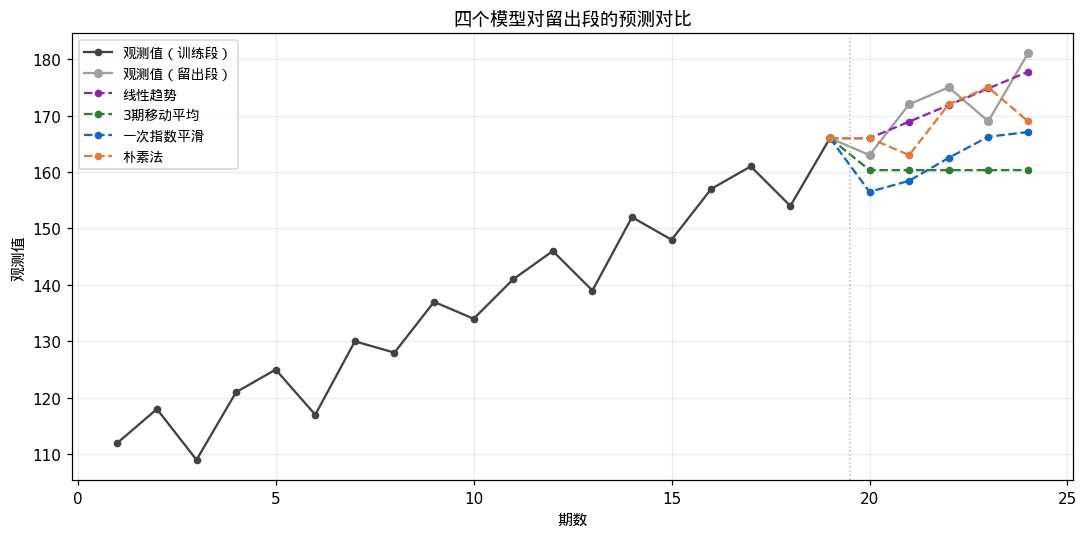

In [6]:
# 四个模型放在同一张图上对比
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, train_n + 1), y[:train_n], "-o", color="#424242",
        ms=4, label="观测值（训练段）")
ax.plot(range(train_n, n + 1), y[train_n - 1:], "-o", color="#9E9E9E",
        ms=5, label="观测值（留出段）")
xf = list(range(train_n, n + 1))
for _name, _r in results.items():
    ax.plot(xf, [y[train_n - 1]] + list(_r["fc"]), "--o",
            color=_r["color"], ms=4, label=_name)
ax.axvline(train_n + 0.5, color="#BBBBBB", ls=":", lw=1)
ax.set_xlabel("期数")
ax.set_ylabel("观测值")
ax.set_title("四个模型对留出段的预测对比")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

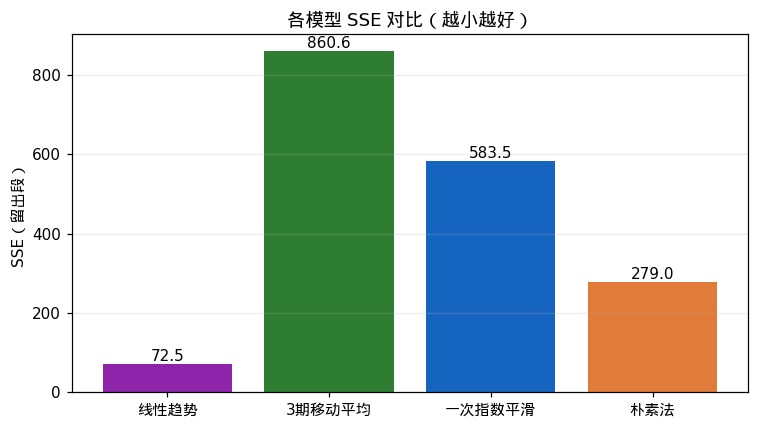

In [7]:
# SSE 柱状对比
_names = list(results)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(_names, [results[k_]["stats"]["SSE"] for k_ in _names],
       color=[results[k_]["color"] for k_ in _names])
for _i, _k in enumerate(_names):
    ax.text(_i, results[_k]["stats"]["SSE"],
            f"{results[_k]['stats']['SSE']:.1f}", ha="center", va="bottom")
ax.set_ylabel("SSE（留出段）")
ax.set_title("各模型 SSE 对比（越小越好）")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

## 6. 留出段逐期对照

In [8]:
# 留出段逐期对照：实际值 vs 各模型预测值
det = pd.DataFrame({"时点": [f"第 {t + 1} 期" for t in t_index],
                    "实际值": [round(v, 4) for v in actual]})
for _name, _r in results.items():
    det[f"{_name} 预测"] = [round(v, 4) for v in _r["fc"]]
    det[f"{_name} 误差"] = [round(e, 4) for e in _r["stats"]["误差"]]
display(det)
print("误差 = 实际值 − 预测值")

,时点,实际值,线性趋势 预测,线性趋势 误差,3期移动平均 预测,3期移动平均 误差,一次指数平滑 预测,一次指数平滑 误差,朴素法 预测,朴素法 误差
0,第 20 期,163.0,165.9825,-2.9825,160.3333,2.6667,156.4888,6.5112,166.0,-3.0
1,第 21 期,172.0,168.9228,3.0772,160.3333,11.6667,158.4422,13.5578,163.0,9.0
2,第 22 期,175.0,171.8632,3.1368,160.3333,14.6667,162.5095,12.4905,172.0,3.0
3,第 23 期,169.0,174.8035,-5.8035,160.3333,8.6667,166.2567,2.7433,175.0,-6.0
4,第 24 期,181.0,177.7439,3.2561,160.3333,20.6667,167.0797,13.9203,169.0,12.0


误差 = 实际值 − 预测值


## 7. 导出 Excel

In [9]:
# 导出 Excel（每张表一个工作表，方便直接拿去用）
_z = z_value()
_pi = pd.DataFrame({"时点": [f"第 {t + 1} 期" for t in t_index]})
for _name, _r in results.items():
    _pi[f"{_name} 预测"] = [round(v, 4) for v in _r["fc"]]
    _pi[f"{_name} SE(h)"] = [round(v, 4) for v in _r["se"]]
    _pi[f"{_name} 区间"] = [f"[{f - _z * s:.4f}, {f + _z * s:.4f}]"
                          for f, s in zip(_r["fc"], _r["se"])]

OUT = "预测结果.xlsx"
with pd.ExcelWriter(OUT, engine="openpyxl") as _w:
    pd.DataFrame({"序号": range(1, n + 1), "观测值": y}).to_excel(
        _w, sheet_name="输入数据", index=False)
    det.to_excel(_w, sheet_name="留出段预测", index=False)
    cmp.to_excel(_w, sheet_name="模型对比", index=False)
    _pi.to_excel(_w, sheet_name="预测区间", index=False)
print(f"已导出 {OUT}（工作表：输入数据 / 留出段预测 / 模型对比 / 预测区间）")


已导出 预测结果.xlsx（工作表：输入数据 / 留出段预测 / 模型对比 / 预测区间）


## 小结

- **SSE / MSE / RMSE / 残差标准误 SE**：越小说明预测误差越小。
- **Theil U1**：0~1 之间的不等系数，越接近 0 越好，可跨模型直接比较。
- **Theil U2**：以「每期都用上一期实际值」的朴素法为基准，小于 1 表示优于朴素法，等于 1 持平，大于 1 更差。
- 数据有明显趋势时，线性趋势模型通常占优；序列比较平稳时，指数平滑和移动平均更有优势。

改数据只需要修改第 2 节里的 `DATA` 和 `FORECAST_START`，然后从头运行一遍即可。